# Lost exporters: abrupt shocks or gradual SRCA decline?

A country–product pair is a **lost exporter** in transition $t \rightarrow t+1$ when $SRCA_{c,p,t} \geq 1$ and $SRCA_{c,p,t+1} < 1$. The unit is therefore a country **for a specific product**, not a country in the aggregate.

A threshold crossing alone cannot establish that a shock caused the loss. This notebook makes the narrower, testable distinction between:

- **Shock-consistent:** a large and historically unusual one-year SRCA fall, no material pre-decline, a concurrent raw-export fall, and an SRCA decomposition dominated by the country–product export term.
- **Gradual decline:** a sustained negative pre-trend followed by a non-abrupt crossing.
- **Ambiguous:** a crossing that does not meet either evidentiary pattern.
- **Insufficient history:** fewer than three pre-event changes are available.

These labels are descriptive evidence about dynamics—not causal identification of a particular external shock.

## 1. Setup and decision rules

All thresholds are collected here for sensitivity analysis. Log changes are preferable to percentage changes because they are symmetric and additive. The 10% annual pre-trend tolerance prevents a mildly noisy series from being called gradual decline.

In [11]:
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

DIGITS = 2
SRCA_CUTOFF = 1.0
ABRUPT_DROP = 0.20           # event SRCA must fall by at least 20%
SURPRISE_Z = -2.0            # event change must be >= 2 robust scales below its history
PRETREND_TOLERANCE = 0.10    # stable means no worse than -10% per year
EXPORT_DROP = 0.20           # raw nominal exports must fall by at least 20%
EPS = 1e-12

def find_repo_root(start=None):
    path = Path(start or Path.cwd()).resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "README.md").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")

ROOT = find_repo_root()
GRAPH_DIR = ROOT / "data" / "5. Graphs Data" / f"{DIGITS}_digits"
ATLAS_DIR = ROOT / "data" / "2. Atlas"
print(f"Repository: {ROOT}")

Repository: /Users/ginof/Documents/code/Detecting-Global-Trade-Vulnerabilities-via-Graph-Neural-Networks


## 2. Load and align SRCA and export data

`SRCA.pickle` contains annual country × product matrices. `CPM.pickle` contains the corresponding raw export values. The latter are also converted to the same smoothed export quantity used inside SRCA so that changes can be decomposed exactly.

In [12]:
with open(GRAPH_DIR / "SRCA.pickle", "rb") as handle:
    srca = pickle.load(handle)
with open(GRAPH_DIR / "CPM.pickle", "rb") as handle:
    cpm_raw = pickle.load(handle)

years = sorted(srca)
country_index = srca[years[0]].index
product_columns = srca[years[0]].columns.astype(str)

exports = {}
for year, matrix in cpm_raw.items():
    matrix = matrix.set_index("country_id") if "country_id" in matrix.columns else matrix.copy()
    matrix.columns = matrix.columns.astype(str)
    exports[year] = matrix.reindex(index=country_index, columns=product_columns, fill_value=0).fillna(0)

# Mirrors compute_SRCA(): current year has weight 2 and up to two prior years weight 1.
smoothed_exports = {}
for year in years:
    prior = [exports[y] for y in range(year - 1, year - 3, -1) if y in exports]
    smoothed_exports[year] = (2 * exports[year] + sum(prior)) / (2 + len(prior))

countries = pd.read_csv(ATLAS_DIR / "countries.csv", encoding="latin1")
country_name = countries.set_index("country_id")["country"].to_dict()

products = pd.read_csv(ATLAS_DIR / "product_hs12.csv", dtype={"code": str})
products["code"] = products["code"].str.zfill(DIGITS)
product_name = (products.loc[products["code"].str.len() == DIGITS]
                .drop_duplicates("code").set_index("code")["name_short_en"].to_dict())

print(f"Coverage: {years[0]}–{years[-1]} | {len(country_index):,} countries | {len(product_columns):,} products")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/ginof/Documents/code/Detecting-Global-Trade-Vulnerabilities-via-Graph-Neural-Networks/data/5. Graphs Data/2_digits/SRCA.pickle'

## 3. Identify every threshold crossing and construct diagnostics

For each crossing, the notebook measures:

1. **Event drop:** $\Delta\log(SRCA)$ from $t$ to $t+1$.
2. **Pre-trend:** OLS slope over $t-3,\ldots,t$ and the number of negative pre-event changes.
3. **Historical surprise:** robust z-score against the pair's three pre-event one-year changes (MAD scale with a 0.05 floor).
4. **Raw export confirmation:** change in the observed export value for that pair.
5. **SRCA decomposition:** whether the decline in the pair's smoothed exports dominates product-market, country-mix, and global denominator movements.
6. **Persistence/recovery:** whether SRCA remains below one in $t+2$ when observable.

In [ ]:
def log_value(value):
    return np.log(max(float(value), EPS))

def classify_events(abrupt_drop=ABRUPT_DROP, surprise_z=SURPRISE_Z,
                    pretrend_tolerance=PRETREND_TOLERANCE, export_drop=EXPORT_DROP):
    rows = []
    for t in years[:-1]:
        nxt = t + 1
        crossing = (srca[t] >= SRCA_CUTOFF) & (srca[nxt] < SRCA_CUTOFF)
        country_pos, product_pos = np.where(crossing.to_numpy())

        # Compute denominator components once per transition, not once per event.
        smooth_t, smooth_next = smoothed_exports[t], smoothed_exports[nxt]
        product_component = -(np.log(smooth_next.sum(axis=0).clip(lower=EPS)) -
                              np.log(smooth_t.sum(axis=0).clip(lower=EPS)))
        country_component = -(np.log(smooth_next.sum(axis=1).clip(lower=EPS)) -
                              np.log(smooth_t.sum(axis=1).clip(lower=EPS)))
        global_component = (log_value(smooth_next.to_numpy().sum()) -
                            log_value(smooth_t.to_numpy().sum()))

        for i, j in zip(country_pos, product_pos):
            cid, product = country_index[i], product_columns[j]
            event_delta = log_value(srca[nxt].iat[i, j]) - log_value(srca[t].iat[i, j])
            available = [y for y in range(t - 3, t + 1) if y in srca]

            enough_history = len(available) == 4
            pre_slope = pre_median_change = robust_scale = surprise = np.nan
            n_negative_prechanges = 0
            if enough_history:
                pre_levels = np.array([log_value(srca[y].iat[i, j]) for y in available])
                pre_changes = np.diff(pre_levels)
                pre_slope = np.polyfit(np.arange(4), pre_levels, 1)[0]
                pre_median_change = np.median(pre_changes)
                mad = np.median(np.abs(pre_changes - pre_median_change))
                robust_scale = max(1.4826 * mad, 0.05)
                surprise = (event_delta - pre_median_change) / robust_scale
                n_negative_prechanges = int((pre_changes < 0).sum())

            raw_t, raw_next = exports[t].iat[i, j], exports[nxt].iat[i, j]
            raw_export_change = raw_next / raw_t - 1 if raw_t > 0 else np.nan

            # Delta log SRCA = own + product-market + country-mix + global.
            own = log_value(smooth_next.iat[i, j]) - log_value(smooth_t.iat[i, j])
            product_market = product_component.iloc[j]
            country_mix = country_component.iloc[i]
            global_market = global_component
            own_dominates = own < 0 and abs(own) > (abs(product_market) + abs(country_mix) + abs(global_market))

            abrupt = enough_history and event_delta <= np.log(1 - abrupt_drop) and surprise <= surprise_z
            stable_before = enough_history and pre_slope >= np.log(1 - pretrend_tolerance)
            declining_before = enough_history and pre_slope < np.log(1 - pretrend_tolerance) and n_negative_prechanges >= 2
            exports_confirm = np.isfinite(raw_export_change) and raw_export_change <= -export_drop

            if not enough_history:
                pattern = "Insufficient history"
            elif abrupt and stable_before and exports_confirm and own_dominates:
                pattern = "Shock-consistent"
            elif declining_before and not abrupt:
                pattern = "Gradual decline"
            else:
                pattern = "Ambiguous"

            future_srca = srca.get(t + 2, pd.DataFrame()).iat[i, j] if t + 2 in srca else np.nan
            rows.append({
                "country_id": cid, "country": country_name.get(cid, str(cid)),
                "product_code": product, "product": product_name.get(product, product),
                "year_t": t, "loss_year": nxt, "srca_t": srca[t].iat[i, j],
                "srca_t1": srca[nxt].iat[i, j], "srca_t2": future_srca,
                "event_log_change": event_delta, "event_pct_change": np.expm1(event_delta),
                "pretrend_log_slope": pre_slope, "surprise_z": surprise,
                "n_negative_prechanges": n_negative_prechanges,
                "raw_exports_t": raw_t, "raw_exports_t1": raw_next,
                "raw_export_pct_change": raw_export_change,
                "own_export_component": own, "product_market_component": product_market,
                "country_mix_component": country_mix, "global_component": global_market,
                "own_component_dominates": own_dominates, "pattern": pattern,
                "persistent_below_one_t2": bool(future_srca < 1) if pd.notna(future_srca) else pd.NA
            })
    return pd.DataFrame(rows)

events = classify_events()
print(f"Lost-exporter country–product events: {len(events):,}")
display(events["pattern"].value_counts().rename_axis("pattern").to_frame("events"))

Lost-exporter country–product events: 32,926


,events
pattern,
Ambiguous,16840
Insufficient history,8945
Shock-consistent,4398
Gradual decline,2743


### Internal consistency check

The four decomposition terms should reconstruct the observed log-SRCA change up to floating-point error. A large error would signal misalignment between the matrices.

In [ ]:
events["decomposition_sum"] = events[["own_export_component", "product_market_component",
                                              "country_mix_component", "global_component"]].sum(axis=1)
# Exact reconstruction is defined only where SRCA is strictly positive; stored structural zeros
# are produced after undefined 0/0 cells are filled and cannot be log-decomposed.
positive_srca = events["srca_t1"] > 0
decomposition_error = (events.loc[positive_srca, "event_log_change"] -
                       events.loc[positive_srca, "decomposition_sum"]).abs()
print(f"Maximum absolute decomposition error (positive SRCA): {decomposition_error.max():.3e}")
print(f"Structural-zero crossings excluded from this check: {(~positive_srca).sum():,}")
assert decomposition_error.max() < 1e-8

Maximum absolute decomposition error (positive SRCA): 1.066e-14
Structural-zero crossings excluded from this check: 3,748


## 4. How common is each pattern?

Early events cannot be classified because the sample begins in 2012. The chart therefore retains “Insufficient history” rather than silently treating those observations as non-shocks.

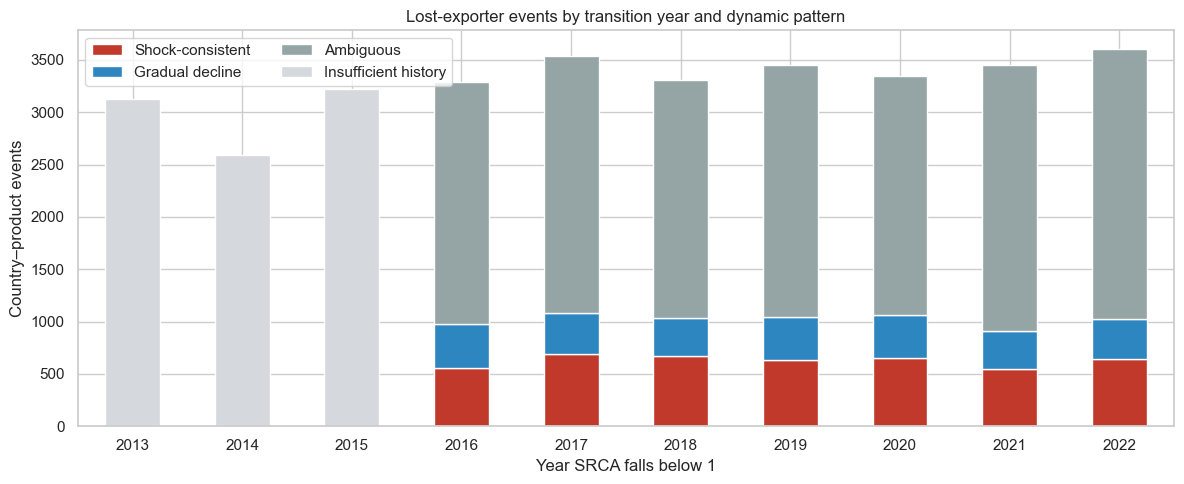

pattern,Shock-consistent,Gradual decline,Ambiguous,Insufficient history,All crossings
country,,,,,
Andorra,59,10,139,95,303
Lebanon,59,44,141,80,324
Panama,56,31,118,76,281
Cyprus,49,22,139,82,292
Democratic People's Republic of Korea,47,5,151,46,249
Guam,47,8,140,29,224
United Republic of Tanzania,45,23,176,47,291
Mauritius,45,20,92,64,221
Grenada,44,8,96,47,195


In [ ]:
order = ["Shock-consistent", "Gradual decline", "Ambiguous", "Insufficient history"]
colors = {"Shock-consistent": "#c0392b", "Gradual decline": "#2e86c1",
          "Ambiguous": "#95a5a6", "Insufficient history": "#d5d8dc"}
annual = events.groupby(["loss_year", "pattern"]).size().unstack(fill_value=0).reindex(columns=order, fill_value=0)
ax = annual.plot(kind="bar", stacked=True, figsize=(12, 5), color=[colors[c] for c in order])
ax.set(title="Lost-exporter events by transition year and dynamic pattern", xlabel="Year SRCA falls below 1", ylabel="Country–product events")
ax.legend(title=None, frameon=True, ncol=2)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

country_summary = (events.groupby(["country", "pattern"]).size().unstack(fill_value=0)
                   .reindex(columns=order, fill_value=0))
country_summary["All crossings"] = country_summary.sum(axis=1)
display(country_summary.sort_values("Shock-consistent", ascending=False).head(15))

## 5. Event-study trajectories

SRCA is normalized to its value at $t$ so pairs with different levels are comparable. A shock-consistent profile should be relatively flat before the event and exhibit a discontinuity at $t+1$; gradual cases should already be falling before $t$. Shading is the interquartile range.

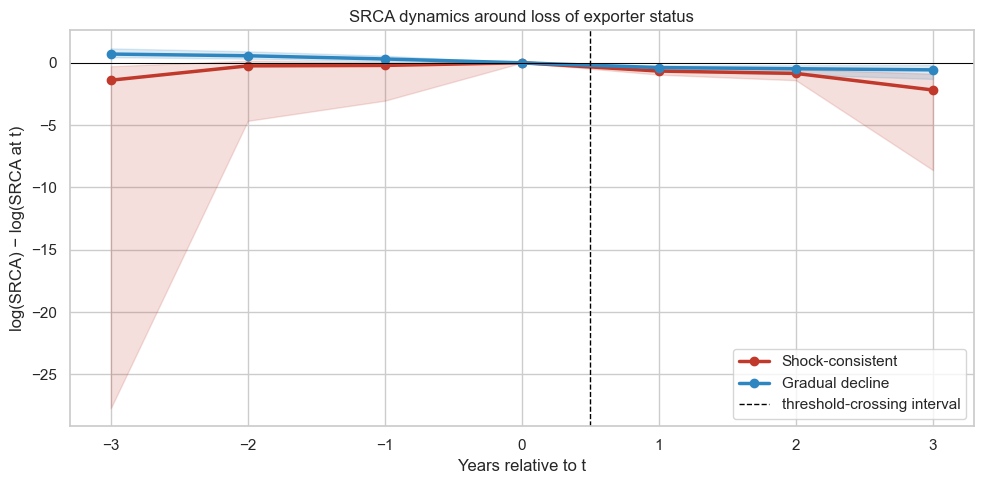

In [ ]:
def event_study_panel(event_frame, window=3):
    records = []
    for row in event_frame.itertuples(index=False):
        i = country_index.get_loc(row.country_id)
        j = product_columns.get_loc(row.product_code)
        base = log_value(srca[row.year_t].iat[i, j])
        for relative_year in range(-window, window + 1):
            year = row.year_t + relative_year
            if year in srca:
                records.append({"pattern": row.pattern, "relative_year": relative_year,
                                "normalized_log_srca": log_value(srca[year].iat[i, j]) - base})
    return pd.DataFrame(records)

study = event_study_panel(events[events["pattern"].isin(["Shock-consistent", "Gradual decline"])])
summary = (study.groupby(["pattern", "relative_year"])["normalized_log_srca"]
           .agg(median="median", q25=lambda x: x.quantile(.25), q75=lambda x: x.quantile(.75)).reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
for pattern in ["Shock-consistent", "Gradual decline"]:
    part = summary[summary["pattern"] == pattern]
    ax.plot(part["relative_year"], part["median"], marker="o", lw=2.5, label=pattern, color=colors[pattern])
    ax.fill_between(part["relative_year"], part["q25"], part["q75"], alpha=.16, color=colors[pattern])
ax.axvline(.5, color="black", ls="--", lw=1, label="threshold-crossing interval")
ax.axhline(0, color="black", lw=.7)
ax.set(title="SRCA dynamics around loss of exporter status", xlabel="Years relative to t",
       ylabel="log(SRCA) − log(SRCA at t)", xticks=range(-3, 4))
ax.legend(frameon=True); plt.tight_layout(); plt.show()

## 6. Abruptness, export confirmation, and persistence

The first panel contrasts event-year SRCA drops with pre-trends. The second asks whether the loss remains one year later. Recovery does not disprove a shock—temporary shocks often reverse—but it distinguishes transitory from persistent losses.

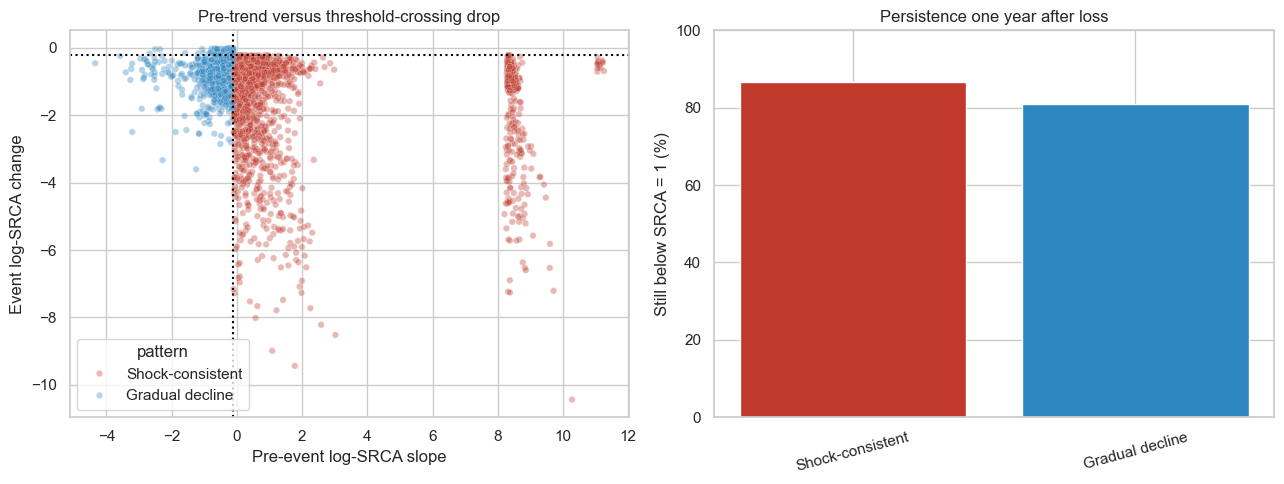

,events,median_srca_drop,median_export_drop,median_pretrend,median_surprise_z,persistence_rate
pattern,,,,,,
Gradual decline,2743,-31.9%,-20.0%,-0.251103,-0.403424,81.1%
Shock-consistent,4398,-48.5%,-94.1%,0.422666,-6.403502,86.5%


In [ ]:
classified = events[events["pattern"].isin(["Shock-consistent", "Gradual decline"])].copy()
sample = classified.sample(min(8000, len(classified)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=sample, x="pretrend_log_slope", y="event_log_change", hue="pattern",
                palette=colors, alpha=.35, s=22, ax=axes[0])
axes[0].axvline(np.log(1 - PRETREND_TOLERANCE), color="black", ls=":")
axes[0].axhline(np.log(1 - ABRUPT_DROP), color="black", ls=":")
axes[0].set(title="Pre-trend versus threshold-crossing drop", xlabel="Pre-event log-SRCA slope", ylabel="Event log-SRCA change")

persistence = (classified.dropna(subset=["persistent_below_one_t2"])
               .groupby("pattern")["persistent_below_one_t2"].mean().reindex(["Shock-consistent", "Gradual decline"]))
axes[1].bar(persistence.index, 100 * persistence.values, color=[colors[x] for x in persistence.index])
axes[1].set(title="Persistence one year after loss", ylabel="Still below SRCA = 1 (%)", ylim=(0, 100))
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

diagnostics = (classified.groupby("pattern")
               .agg(events=("pattern", "size"), median_srca_drop=("event_pct_change", "median"),
                    median_export_drop=("raw_export_pct_change", "median"),
                    median_pretrend=("pretrend_log_slope", "median"),
                    median_surprise_z=("surprise_z", "median"),
                    persistence_rate=("persistent_below_one_t2", "mean")))
display(diagnostics.style.format({c: "{:.1%}" for c in ["median_srca_drop", "median_export_drop", "persistence_rate"]}))

## 7. Inspect representative events

These tables make the classification auditable. Extreme shock-consistent cases are ranked by historical surprise; gradual cases by the steepness of the pre-trend. Treat tiny trade flows cautiously even when their SRCA is high.

In [ ]:
show_cols = ["country", "product_code", "product", "year_t", "loss_year", "srca_t", "srca_t1",
             "event_pct_change", "raw_export_pct_change", "pretrend_log_slope", "surprise_z",
             "own_export_component", "persistent_below_one_t2"]
print("Most historically unusual shock-consistent events")
display(events.query("pattern == 'Shock-consistent'").nsmallest(15, "surprise_z")[show_cols])
print("Strongest gradual pre-declines")
display(events.query("pattern == 'Gradual decline'").nsmallest(15, "pretrend_log_slope")[show_cols])

Most historically unusual shock-consistent events


,country,product_code,product,year_t,loss_year,srca_t,srca_t1,event_pct_change,raw_export_pct_change,pretrend_log_slope,surprise_z,own_export_component,persistent_below_one_t2
30569,Iran (Islamic Republic of),2705,Non-petroleum gases,2021,2022,61.870542,0.042717,-0.999310,-1.000000,-0.066864,-144.134400,-8.081058,<NA>
17311,Malawi,8606,"Railway cars, not self-propelled",2017,2018,3.898597,0.015040,-0.996142,-1.000000,0.153905,-106.208072,-5.969170,True
23815,Democratic People's Republic of Korea,6202,"Womens overcoats, not knit",2019,2020,33.946154,0.198292,-0.994159,-0.831942,-0.034550,-101.236852,-6.259288,True
27186,Republic of Korea,8469,"Typewriters, word-processers",2020,2021,2.638232,0.077249,-0.970720,-1.000000,1.184945,-98.109113,-4.816757,True
20828,Nepal,2003,"Mushrooms, prepared or preserved",2018,2019,1.026709,0.012298,-0.988022,-1.000000,-0.052335,-79.835169,-4.173999,True
32527,Samoa,8528,Monitors and projectors,2021,2022,1.590475,0.022188,-0.986049,-1.000000,0.026106,-77.827534,-4.431041,<NA>
32467,Venezuela (Bolivarian Republic of),0510,Animal products used in pharmaceuticals,2021,2022,1.036692,0.037714,-0.963621,-1.000000,0.019779,-70.104041,-3.126522,<NA>
13524,Kazakhstan,8102,Molybdenum and articles thereof,2016,2017,2.614177,0.002828,-0.998918,-1.000000,0.049453,-63.577254,-6.993135,True
23809,Democratic People's Republic of Korea,6104,"Women's suits, knit",2019,2020,2.081891,0.008577,-0.995880,-1.000000,0.094981,-60.063675,-6.577259,True
18896,British Indian Ocean Territory,9207,"Musical instruments, electric",2017,2018,8.390304,0.333482,-0.960254,-1.000000,-0.000327,-58.949908,-3.640288,True


Strongest gradual pre-declines


,country,product_code,product,year_t,loss_year,srca_t,srca_t1,event_pct_change,raw_export_pct_change,pretrend_log_slope,surprise_z,own_export_component,persistent_below_one_t2
28694,Turks and Caicos Islands,8206,Retail tool sets,2020,2021,1.150797,0.724932,-0.370061,-1.000000,-4.346605,-0.011064,-0.693147,False
22495,Pitcairn,6402,Other footwear of rubber or plastics,2018,2019,1.059173,0.828205,-0.218065,-0.772201,-3.579405,-0.000958,-0.317731,True
16466,Dominica,6310,Used or new rags textile scraps,2017,2018,1.343926,0.646972,-0.518596,-1.000000,-3.407474,-0.008645,-0.693147,False
25689,Saint Barthélemy,3301,Essential oils,2019,2020,2.247504,0.865329,-0.614982,-1.000000,-3.266016,-0.009418,-0.693147,True
15529,Norfolk Island,7326,Other articles of iron or steel,2016,2017,1.249883,0.666592,-0.466676,-1.000000,-3.243264,-0.012155,-0.693147,True
12494,British Virgin Islands,3817,Mixed alkylbenzenes,2016,2017,1.534880,0.956519,-0.376812,-1.000000,-3.213427,-0.011016,-0.693147,False
32106,Tokelau,5511,"Yarn of synthetic staple fibers, for retail sale",2021,2022,2.846495,0.234230,-0.917713,-1.000000,-3.211116,-0.004806,-0.693147,<NA>
20885,Curaçao,3101,Animal or vegetable fertilizers,2018,2019,1.076342,0.779564,-0.275728,-1.000000,-2.959714,0.009844,-0.693147,False
32767,Saint Barthélemy,7307,Tube or pipe fittings of iron or steel,2021,2022,3.015330,0.493727,-0.836261,-0.539060,-2.918707,-0.027497,-0.039843,<NA>
22384,Cocos (Keeling) Islands,6201,"Men's overcoats, not knit",2018,2019,1.381621,0.714084,-0.483155,-1.000000,-2.909188,-0.005777,-0.693147,True


## 8. Threshold sensitivity

A credible conclusion should not depend on one arbitrary cutoff. This grid varies the minimum event drop and historical-surprise threshold while retaining the export, pre-trend, and decomposition checks.

In [ ]:
sensitivity_rows = []
eligible = events.dropna(subset=["surprise_z", "pretrend_log_slope"]).copy()
for minimum_drop in [0.10, 0.20, 0.30]:
    for z_cutoff in [-1.5, -2.0, -2.5]:
        flag = (eligible["event_log_change"] <= np.log(1 - minimum_drop)) & (eligible["surprise_z"] <= z_cutoff)
        flag &= eligible["pretrend_log_slope"] >= np.log(1 - PRETREND_TOLERANCE)
        flag &= eligible["raw_export_pct_change"] <= -EXPORT_DROP
        flag &= eligible["own_component_dominates"]
        sensitivity_rows.append({"minimum_SRCA_drop": minimum_drop, "surprise_z_cutoff": z_cutoff,
                                 "shock_consistent_events": int(flag.sum()),
                                 "share_of_classifiable_crossings": flag.mean()})
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.pivot(index="minimum_SRCA_drop", columns="surprise_z_cutoff", values="shock_consistent_events"))
display(sensitivity.pivot(index="minimum_SRCA_drop", columns="surprise_z_cutoff", values="share_of_classifiable_crossings")
        .style.format("{:.1%}"))

surprise_z_cutoff,-2.5,-2.0,-1.5
minimum_SRCA_drop,,,
0.1,4159,4710,5483
0.2,3911,4398,5089
0.3,3437,3843,4451


surprise_z_cutoff,-2.500000,-2.000000,-1.500000
minimum_SRCA_drop,,,
0.100000,17.3%,19.6%,22.9%
0.200000,16.3%,18.3%,21.2%
0.300000,14.3%,16.0%,18.6%


## 9. Export the event-level evidence

The exported file preserves every crossing and every diagnostic, so downstream models can use the conservative `Shock-consistent` subset or perform their own relabelling.

In [ ]:
output_path = GRAPH_DIR / "SRCA_decline_events.csv"
events.to_csv(output_path, index=False)
print(f"Saved {len(events):,} event rows to {output_path.relative_to(ROOT)}")

Saved 32,926 event rows to data/5. Graphs Data/4_digits/SRCA_decline_events.csv


## Interpretation and recommended extensions

A clean result is a visible pre-event separation in the event-study plot: shock-consistent cases remain approximately stable until a discrete fall, while gradual cases slope downward beforehand. Concurrent export collapse, dominance of the own-export decomposition term, and persistence add corroboration. None of these alone identifies the cause.

For a paper-strength causal claim, the most useful next steps are:

1. **Link external shocks explicitly.** Build a country–year shock table (sanctions, conflict onset, disasters, coups, port closures, or policy bans) and test whether abrupt losses cluster in exposed country–years and products.
2. **Matched event study / difference-in-differences.** Match each exposed country–product to pairs with similar pre-event SRCA, exports, product, and trend; test for differential post-event decline and pre-trend balance.
3. **Unsmoothing robustness.** Repeat with ordinary annual RCA and export quantity where available. Because SRCA averages current and prior exports, a one-year discontinuity that survives smoothing is notable, but smoothing also delays and attenuates shocks.
4. **Threshold-margin robustness.** Exclude crossings close to one (for example require $SRCA_t \geq 1.1$ and $SRCA_{t+1} \leq 0.9$) to reduce mechanical label noise.
5. **Economic-materiality filter.** Require a minimum pre-event export value or global product share so very small flows do not drive counts. Report both event counts and export-weighted results.
6. **Separate temporary and persistent shocks.** Report recovery within one or two years and cumulative export loss; a transient shock and structural exit have different implications.
7. **Inference at the shock level.** Country–product events share country, product, and year shocks. Use clustered uncertainty (at least country and product, ideally shock episode) rather than treating all pairs as independent.